In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing, linear_model
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing, linear_model
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# =========================
# 1. Load Data
# =========================
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

In [ ]:
# =========================
# 2. Data Cleaning
# =========================
df = df.drop([
    'MODELYEAR', 'MAKE', 'MODEL',
    'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',
    'CYLINDERS',
    'FUELCONSUMPTION_CITY',
    'FUELCONSUMPTION_HWY',
    'FUELCONSUMPTION_COMB'
], axis=1)

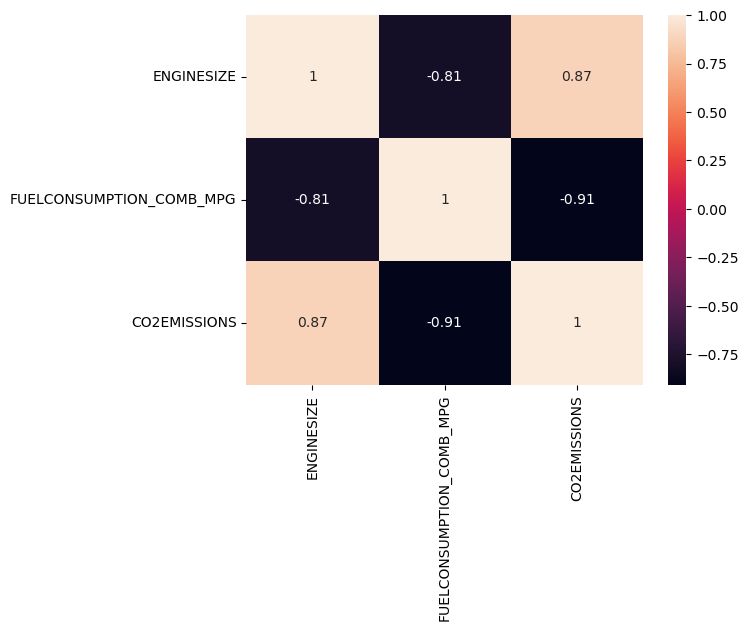

In [4]:
# =========================
# 3. EDA (optional)
# =========================
sns.heatmap(df.corr(), annot=True)
plt.show()

In [5]:
# =========================
# 4. Features & Target
# =========================
x = df.iloc[:, [0, 1]].to_numpy()   # ENGINESIZE, FUELCONSUMPTION_COMB
y = df.iloc[:, [2]].to_numpy()       # CO2 EMISSIONS

In [ ]:
# =========================
# 5. Scaling
# =========================
scaler = preprocessing.StandardScaler()
x_scaled = scaler.fit_transform(x)

# =========================
# 6. Train/Test Split
# =========================
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# =========================
# 7. Train Model
# =========================
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

coef = model.coef_
intercept = model.intercept_

print("Coefficients:", coef)
print("Intercept:", intercept)

Coefficients: [[ 25.27339614 -37.4381472 ]]
Intercept: [256.29072488]


In [ ]:
# =========================
# 8. 3D Visualization Prep
# =========================
x1 = x_test[:, 0]
x2 = x_test[:, 1]

x1_surf, x2_surf = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 100),
    np.linspace(x2.min(), x2.max(), 100)
)

y_surf = intercept + coef[0, 0] * x1_surf + coef[0, 1] * x2_surf

# Predictions (FIXED)
y_pred = model.predict(x_test)

above_plane = (y_test[:, 0] >= y_pred[:, 0])
below_plane = ~above_plane

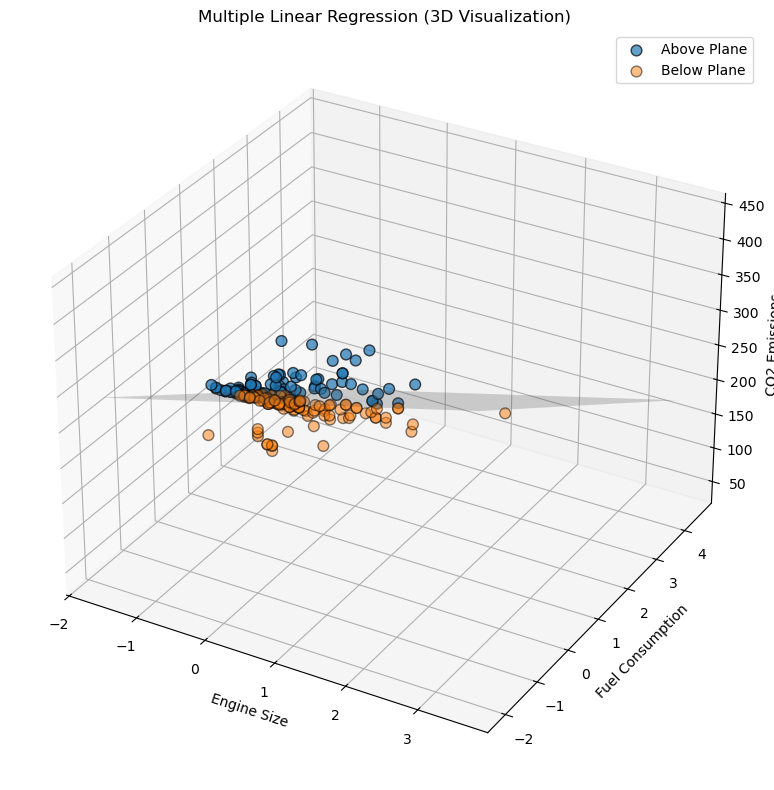

In [ ]:
# =========================
# 9. 3D Plot
# =========================
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1[above_plane], x2[above_plane], y_test[above_plane, 0],
           label="Above Plane", s=60, alpha=0.7, edgecolor='k')

ax.scatter(x1[below_plane], x2[below_plane], y_test[below_plane, 0],
           label="Below Plane", s=60, alpha=0.5, edgecolor='k')

ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.25, color='gray')

ax.set_xlabel("Engine Size")
ax.set_ylabel("Fuel Consumption")
ax.set_zlabel("CO2 Emissions")
ax.set_title("Multiple Linear Regression (3D Visualization)")

ax.legend()
plt.tight_layout()
plt.show()

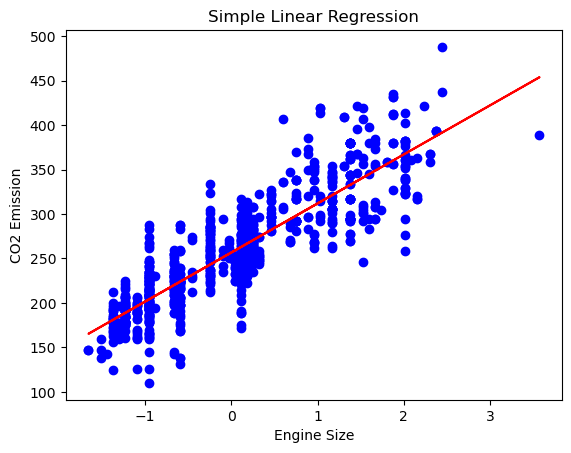

In [10]:
# =========================
# 10. Simple 2D Regression (Engine Size only)
# =========================
x_train_1 = x_train[:, 0].reshape(-1, 1)

model_1 = linear_model.LinearRegression()
model_1.fit(x_train_1, y_train)

plt.scatter(x_train_1, y_train, color='blue')
plt.plot(x_train_1, model_1.predict(x_train_1), color='red')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression")
plt.show()

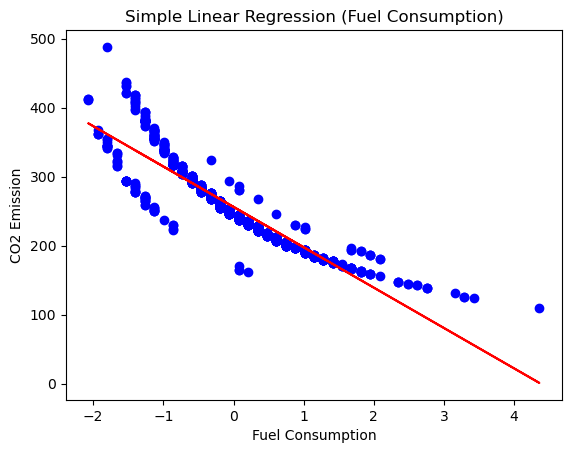

In [11]:
# =========================
# 11. Second Feature Model
# =========================
x_train_2 = x_train[:, 1].reshape(-1, 1)

model_2 = linear_model.LinearRegression()
model_2.fit(x_train_2, y_train)

plt.scatter(x_train_2, y_train, color='blue')
plt.plot(x_train_2, model_2.predict(x_train_2), color='red')
plt.xlabel("Fuel Consumption")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression (Fuel Consumption)")
plt.show()